# 01 — Análisis Operacional — LockBit Panel

Análisis de datos estructurados **sin LLM**: jerarquía de operadores, ciclo de vida  
de víctimas, evolución de builds y funnel de pagos.

Requiere haber ejecutado primero `00_extract_and_explore.ipynb`.

## 0. Setup

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

PROCESSED = Path('../data/processed')

for t in ['users', 'clients', 'chats', 'builds', 'invites']:
    assert (PROCESSED / f'{t}.parquet').exists(), f'Falta {t}.parquet — ejecuta notebook 00'

users   = pd.read_parquet(PROCESSED / 'users.parquet')
clients = pd.read_parquet(PROCESSED / 'clients.parquet')
chats   = pd.read_parquet(PROCESSED / 'chats.parquet')
builds  = pd.read_parquet(PROCESSED / 'builds.parquet')
invites = pd.read_parquet(PROCESSED / 'invites.parquet')

print('Datos cargados OK')

Datos cargados OK


## 1. Jerarquía de operadores

El campo `permissions` es un JSON array con los módulos habilitados para cada afiliado.  
El campo `level` indica jerarquía: 4 = admin, 1 = afiliado estándar.

In [2]:
def parse_permissions(perm_str):
    try:
        return json.loads(perm_str) if perm_str else []
    except Exception:
        return []

users['perms_list'] = users['permissions'].apply(parse_permissions)
users['n_perms'] = users['perms_list'].apply(len)

# Mapa nivel → etiqueta
level_map = {4: 'Admin', 3: 'Manager', 2: 'Senior', 1: 'Afiliado'}
users['role'] = users['level'].map(level_map).fillna('Desconocido')

print('=== JERARQUÍA ===')
print(users.groupby('role')['login'].count().to_string())
print()
print('Operadores con más permisos:')
print(users[['login','role','tag','n_perms','last_online_dt']].sort_values('n_perms', ascending=False).head(10).to_string())

=== JERARQUÍA ===
role
Admin        1
Afiliado    74

Operadores con más permisos:
              login      role       tag  n_perms            last_online_dt
0             admin     Admin                 10 2025-04-29 12:46:02+00:00
1         matrix777  Afiliado                 10 2025-04-29 11:29:42+00:00
2             fedor  Afiliado    newbie       10 2024-12-19 00:10:02+00:00
3        KeaynBaker  Afiliado    newbie       10 2024-12-19 01:20:25+00:00
4              five  Afiliado    newbie       10 2024-12-20 14:57:05+00:00
5        OranBarnes  Afiliado    newbie       10 2025-01-31 13:44:07+00:00
6      BroganAlbert  Afiliado    newbie       10 2024-12-19 00:33:22+00:00
7   FezaanBlanchard  Afiliado    newbie       10 2024-12-19 00:34:39+00:00
8  ArdalBlankenship  Afiliado    newbie       10 2025-02-14 20:25:14+00:00
9             Brown  Afiliado  verified       10 2025-04-03 13:40:39+00:00


In [3]:
# Actividad de operadores: cuántos builds y víctimas tiene cada uno
op_builds  = builds.groupby('userid').size().rename('n_builds')
op_victims = clients.groupby('advid').size().rename('n_victims')
op_chats   = chats[chats.flag == 1].groupby('advid').size().rename('n_chat_msgs')

op_stats = (users.set_index('id')
            .join(op_builds, how='left')
            .join(op_victims, how='left')
            .join(op_chats, how='left')
            .fillna(0)
            .sort_values('n_victims', ascending=False))

print('Top 20 operadores por víctimas asignadas:')
display(op_stats[['login','role','tag','n_victims','n_builds','n_chat_msgs','last_online_dt']].head(20))

Top 20 operadores por víctimas asignadas:


,login,role,tag,n_victims,n_builds,n_chat_msgs,last_online_dt
id,,,,,,,
25,Christopher,Afiliado,verified,44.0,70.0,1073.0,2025-04-29 06:18:30+00:00
18,jhon0722,Afiliado,newbie,42.0,16.0,9.0,2025-04-21 05:15:58+00:00
12,PiotrBond,Afiliado,newbie,19.0,53.0,134.0,2025-04-29 11:09:36+00:00
43,JamesCraig,Afiliado,verified,17.0,170.0,152.0,2025-04-29 05:42:46+00:00
70,Swan,Afiliado,verified,17.0,147.0,142.0,2025-04-29 13:23:24+00:00
65,Iofikdis,Afiliado,newbie,12.0,79.0,248.0,2025-04-29 11:17:03+00:00
28,umarbishop47,Afiliado,newbie,10.0,74.0,71.0,2025-04-29 11:49:13+00:00
15,Anon666,Afiliado,newbie,7.0,32.0,26.0,2025-03-28 21:51:31+00:00
21,smelly,Afiliado,newbie,7.0,15.0,2.0,2024-12-23 16:53:57+00:00


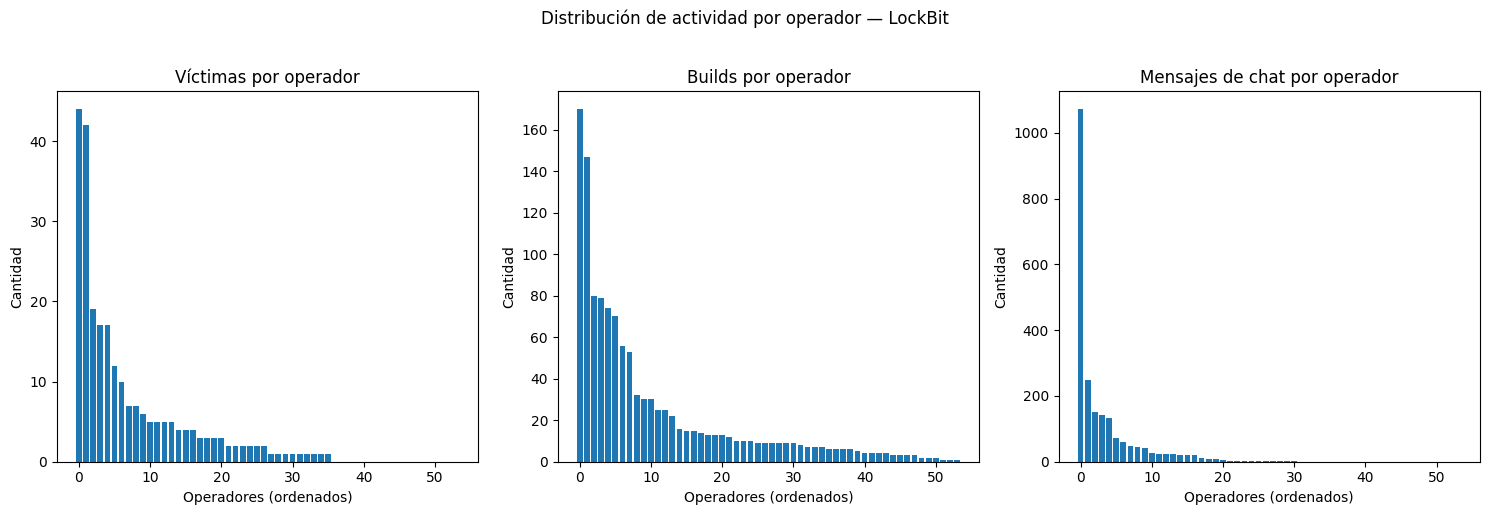

In [4]:
# Distribución de actividad por operador
active = op_stats[(op_stats.n_victims > 0) | (op_stats.n_builds > 0)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                          ['n_victims', 'n_builds', 'n_chat_msgs'],
                          ['Víctimas por operador', 'Builds por operador', 'Mensajes de chat por operador']):
    data = active[col].sort_values(ascending=False)
    ax.bar(range(len(data)), data.values)
    ax.set_title(title)
    ax.set_xlabel('Operadores (ordenados)')
    ax.set_ylabel('Cantidad')

plt.suptitle('Distribución de actividad por operador — LockBit', y=1.02)
plt.tight_layout()
plt.show()

## 2. Ciclo de vida de víctimas

Seguimiento desde el primer acceso al panel hasta el pago (si se produce).

In [5]:
# Tiempo de permanencia (desde primer acceso hasta último)
clients['days_active'] = (clients['date_last'] - clients['date_first']).dt.total_seconds() / 86400
clients_valid = clients.dropna(subset=['days_active'])

print('=== CICLO DE VIDA DE VÍCTIMAS ===')
print(f'Tiempo activo mediana : {clients_valid.days_active.median():.1f} días')
print(f'Tiempo activo máx     : {clients_valid.days_active.max():.0f} días')
print(f'Vistas al panel (median): {clients.views.median():.0f}')
print()

# Funnel de estados
total = len(clients)
with_chat  = clients.id.isin(chats.clientid).sum()
paid       = (clients.paid_commission == 1).sum()
decrypted  = (clients.decrypt_done > 0).sum()

print('=== FUNNEL DE CONVERSIÓN ===')
print(f'  1. Víctimas en panel       : {total:>4}  (100%)')
print(f'  2. Con chat iniciado       : {with_chat:>4}  ({with_chat/total*100:.1f}%)')
print(f'  3. Pagaron comisión        : {paid:>4}  ({paid/total*100:.1f}%)')
print(f'  4. Descifrado completado   : {decrypted:>4}  ({decrypted/total*100:.1f}%)')

=== CICLO DE VIDA DE VÍCTIMAS ===
Tiempo activo mediana : 0.0 días
Tiempo activo máx     : 123 días
Vistas al panel (median): 11

=== FUNNEL DE CONVERSIÓN ===
  1. Víctimas en panel       :  246  (100%)
  2. Con chat iniciado       :  208  (84.6%)
  3. Pagaron comisión        :    7  (2.8%)
  4. Descifrado completado   :    0  (0.0%)


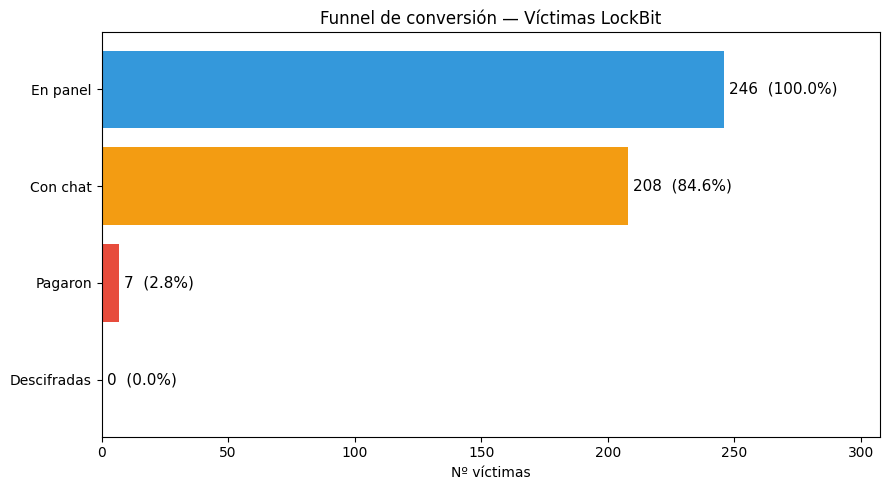

In [6]:
# Visualización del funnel
stages = ['En panel', 'Con chat', 'Pagaron', 'Descifradas']
counts = [total, with_chat, paid, decrypted]
colors = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1])
for bar, n in zip(bars, counts[::-1]):
    pct = n / total * 100
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{n}  ({pct:.1f}%)', va='center', fontsize=11)
ax.set_xlim(0, total * 1.25)
ax.set_title('Funnel de conversión — Víctimas LockBit')
ax.set_xlabel('Nº víctimas')
plt.tight_layout()
plt.show()

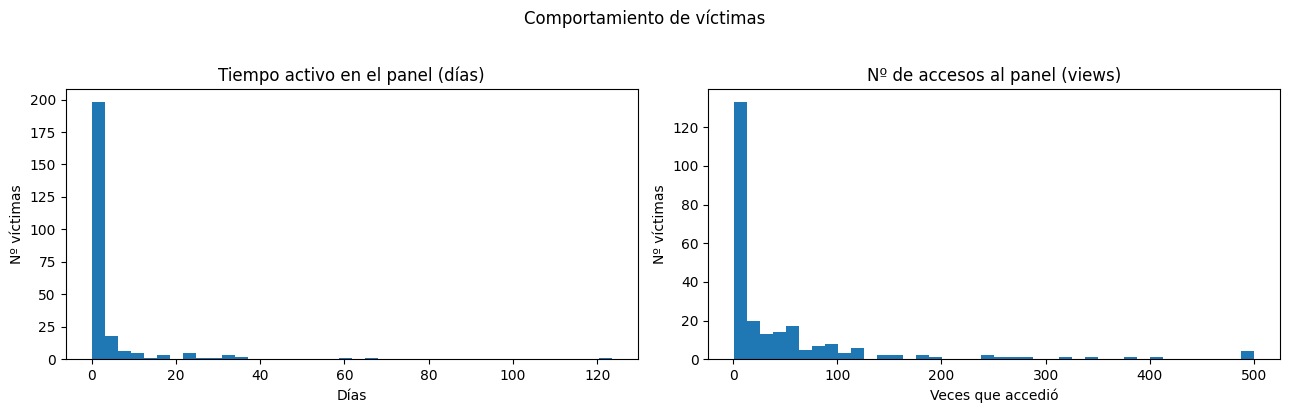

In [7]:
# Distribución de tiempo de permanencia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(clients_valid.days_active.clip(upper=180), bins=40, edgecolor='none')
axes[0].set_title('Tiempo activo en el panel (días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Nº víctimas')

axes[1].hist(clients.views.clip(upper=500), bins=40, edgecolor='none')
axes[1].set_title('Nº de accesos al panel (views)')
axes[1].set_xlabel('Veces que accedió')
axes[1].set_ylabel('Nº víctimas')

plt.suptitle('Comportamiento de víctimas', y=1.02)
plt.tight_layout()
plt.show()

## 3. Evolución de builds de malware

LockBit usa variantes identificadas por tipo (25, 30, 40, 46, 50).  
Cada build puede estar asociado a una víctima específica (`company_website`).

In [8]:
builds_valid = builds.dropna(subset=['date'])
type_names = {25: 'LB 2.5', 30: 'LB 3.0', 40: 'LB 4.0', 46: 'LB 4.6', 50: 'LB 5.0'}

print('=== BUILDS DE MALWARE ===')
print(f'Total builds: {len(builds)}')
print(f'Operadores que crearon builds: {builds.userid.nunique()}')
print()
for t, cnt in builds.type.value_counts().sort_index().items():
    print(f'  Tipo {t} ({type_names.get(t, "?")}): {cnt:4d} builds')

=== BUILDS DE MALWARE ===
Total builds: 1183
Operadores que crearon builds: 54

  Tipo 25 (LB 2.5):  297 builds
  Tipo 30 (LB 3.0):  504 builds
  Tipo 40 (LB 4.0):  143 builds
  Tipo 46 (LB 4.6):  151 builds
  Tipo 50 (LB 5.0):   88 builds


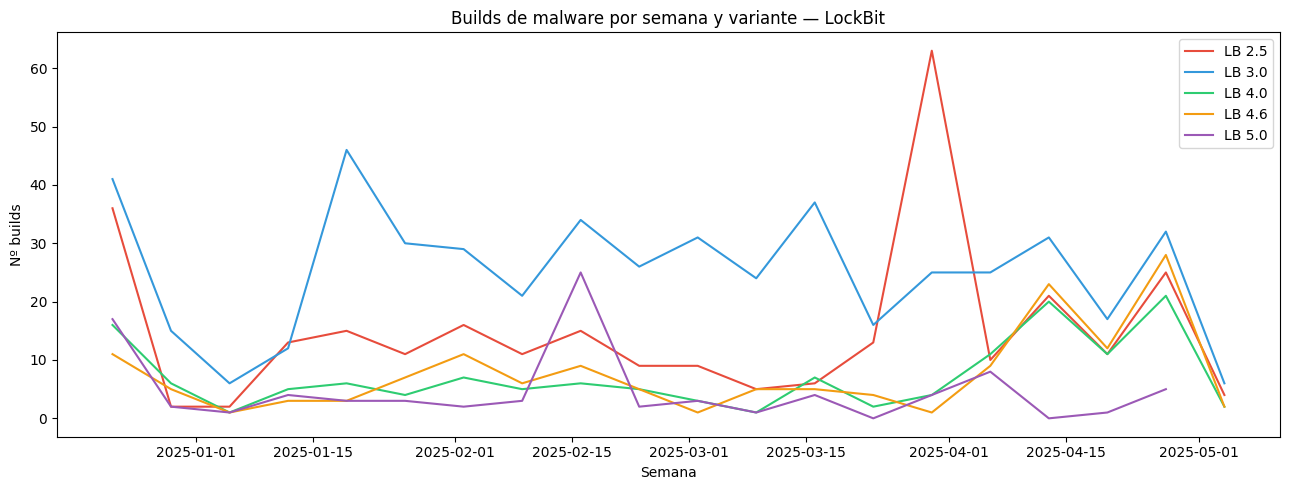

In [9]:
# Evolución temporal por tipo
type_colors = {25: '#e74c3c', 30: '#3498db', 40: '#2ecc71', 46: '#f39c12', 50: '#9b59b6'}

fig, ax = plt.subplots(figsize=(13, 5))

for btype in sorted(builds_valid.type.unique()):
    sub = builds_valid[builds_valid.type == btype].set_index('date').resample('W').size()
    ax.plot(sub.index, sub.values, label=type_names.get(btype, str(btype)),
            color=type_colors.get(btype, '#95a5a6'), linewidth=1.5)

ax.set_title('Builds de malware por semana y variante — LockBit')
ax.set_xlabel('Semana')
ax.set_ylabel('Nº builds')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Estructura de reclutamiento (invites)

In [10]:
invites['amount_f'] = pd.to_numeric(invites['amount'], errors='coerce')
invites['crypto'] = invites.apply(
    lambda r: 'BTC' if pd.notna(r.btc_wallet) else ('XMR' if pd.notna(r.monero_wallet) else 'N/A'), axis=1
)

print('=== INVITES DE AFILIACIÓN ===')
print(f'Total invites creados : {len(invites)}')
print(f'Aceptadas (status=50) : {(invites.status==50).sum()}')
print(f'Pendientes (status=0) : {(invites.status==0).sum()}')
print()
print('Por criptomoneda:')
print(invites.crypto.value_counts().to_string())
print()
print('Montos pagados para afiliarse:')
print(invites.groupby('crypto')['amount_f'].describe().round(4).to_string())

# Timeline de invites
inv_daily = invites.dropna(subset=['created_at']).set_index('created_at').resample('D').size()
print(f'\nPico de reclutamiento: {inv_daily.idxmax().date()}  ({inv_daily.max()} invites/día)')

=== INVITES DE AFILIACIÓN ===
Total invites creados : 3693
Aceptadas (status=50) : 72
Pendientes (status=0) : 3449

Por criptomoneda:
crypto
BTC    2338
XMR    1355

Montos pagados para afiliarse:
         count    mean     std     min     25%     50%     75%     max
crypto                                                                
BTC     2338.0  0.0084  0.0007  0.0072  0.0079  0.0082  0.0091  0.0103
XMR     1355.0  3.6739  0.2638  2.7825  3.4903  3.6242  3.8222  4.6107

Pico de reclutamiento: 2024-12-19  (294 invites/día)


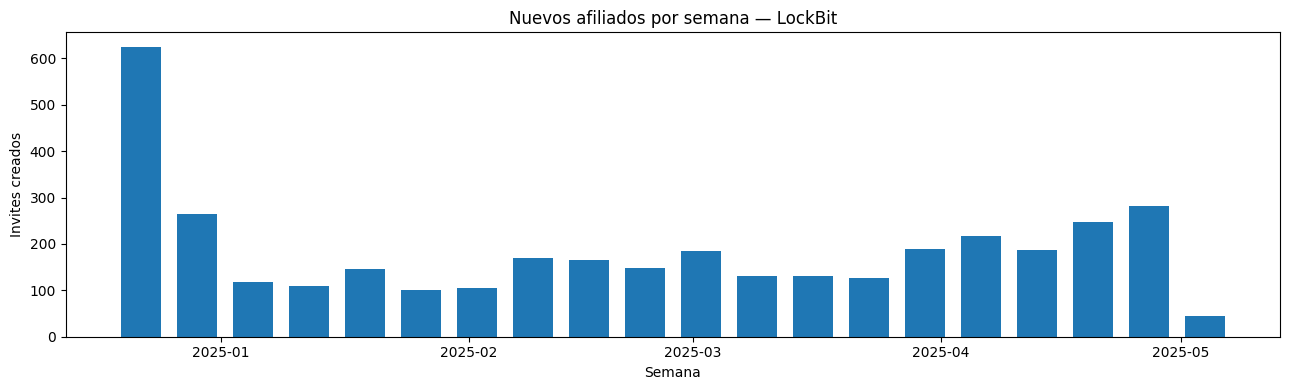

In [11]:
# Timeline de invites
inv_weekly = invites.dropna(subset=['created_at']).set_index('created_at').resample('W').size()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(inv_weekly.index, inv_weekly.values, width=5)
ax.set_title('Nuevos afiliados por semana — LockBit')
ax.set_xlabel('Semana')
ax.set_ylabel('Invites creados')
plt.tight_layout()
plt.show()

## 5. Relaciones operador → víctima → build

Mapa de la estructura operacional: qué operadores controlan qué víctimas  
y qué variante de malware usaron.

In [12]:
# Join clients ↔ builds ↔ users
enriched = (clients
            .merge(builds[['id','type','company_website','revenue']].rename(columns={'id':'build_id'}),
                   on='build_id', how='left')
            .merge(users[['id','login']].rename(columns={'id':'advid','login':'operator'}),
                   on='advid', how='left'))

print('Distribución de variante de malware usada por las víctimas:')
print(enriched.type.value_counts().map(lambda t: f'{t} víctimas').to_string())
print()
print('Operadores con más víctimas (top 10):')
print(enriched.groupby('operator').size().sort_values(ascending=False).head(10).to_string())

Distribución de variante de malware usada por las víctimas:
type
30    168 víctimas
25     31 víctimas
46     24 víctimas
50     21 víctimas
40      2 víctimas

Operadores con más víctimas (top 10):
operator
Christopher      44
jhon0722         42
PiotrBond        19
JamesCraig       17
Swan             17
Iofikdis         12
umarbishop47     10
Anon666           7
smelly            7
btcdrugdealer     6


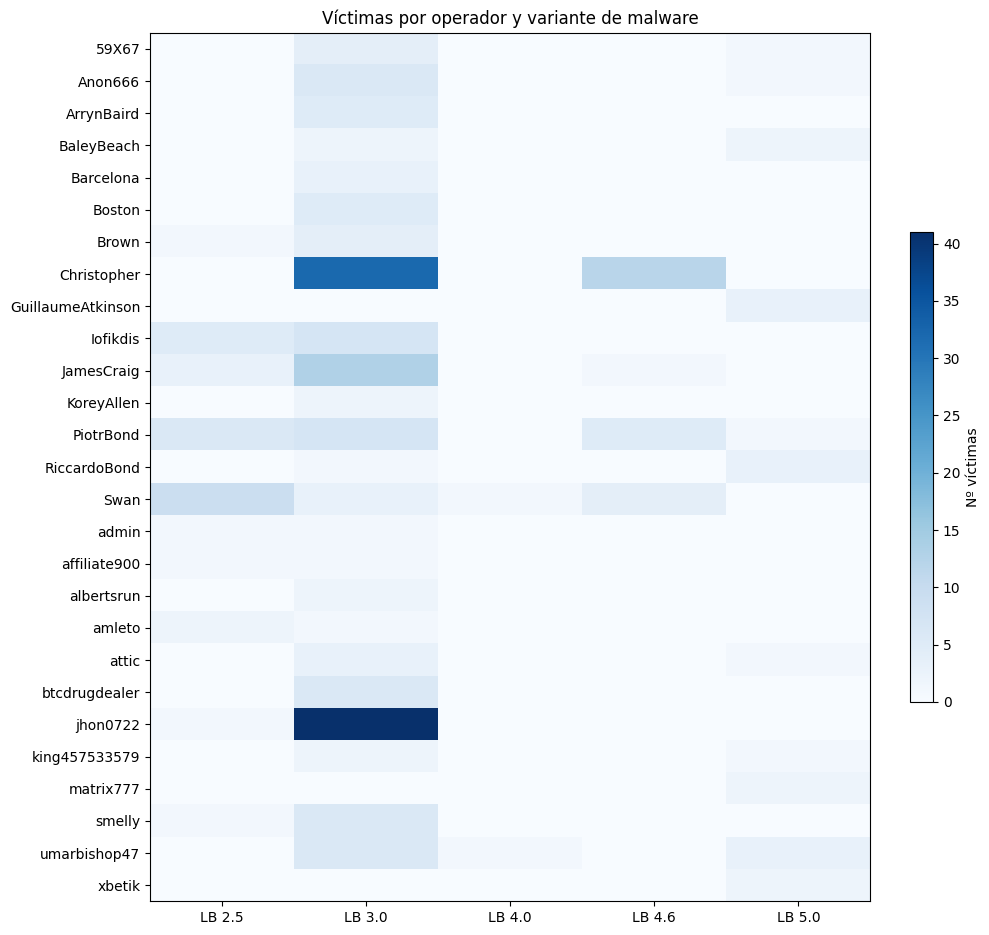

In [13]:
# Heatmap operador × tipo de build
pivot = enriched.groupby(['operator', 'type']).size().unstack(fill_value=0)
pivot = pivot[pivot.sum(axis=1) >= 2]  # solo operadores con ≥2 víctimas

if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.35)))
    im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([type_names.get(c, str(c)) for c in pivot.columns])
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, fraction=0.03, label='Nº víctimas')
    ax.set_title('Víctimas por operador y variante de malware')
    plt.tight_layout()
    plt.show()